<a href="https://colab.research.google.com/github/basileplus/neural_LFT/blob/main/neural_LFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notation :
  θ  : primal variable  (input to f)
  η  : dual variable    (input to f*)
  f' : preconditioned function
  z  : preconditioned primal variable,  z = H^{1/2}(θ − θ_0)
  η' : preconditioned dual variable,    η' = η H^{-1/2}

All plots project onto the first coordinate (θ_1 or η_1).

In [338]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


# Architecture

We define the neural networks here. ICNN to model our function $f$ and a residual network to learn the conjugation

In [339]:
class PositiveLinear(nn.Module):
    """Linear layer with W >= 0 for ICNN layers"""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.W = nn.Parameter(torch.randn(in_dim, out_dim) * 0.1)

    def forward(self, x):
        return x @ self.W.clamp(min=0)


class ICNN(nn.Module):
    """
    Input-Convex Neural Network  f : R^d -> R.
    Recurrence: z_{t+1} = σ(W_t z_t + A_t θ),  W_t ≥ 0,  σ = softplus.
    A final PositiveLinear layer outputs a scalar.
    """
    def __init__(self, d, h=16, depth=4, strong_convexity=0.1):
        super().__init__()
        self.strong_convexity = strong_convexity
        self.Ws  = nn.ModuleList([
            PositiveLinear(h, h) for _ in range(depth - 1)
        ])
        self.As  = nn.ModuleList([
            nn.Linear(d, h) for _ in range(depth)
        ])
        self.out = PositiveLinear(h, 1)

    def forward(self, theta):
        z = F.softplus(self.As[0](theta))
        for W, A in zip(self.Ws, self.As[1:]):
            z = F.softplus(W(z) + A(theta))
        quad = 0.5 * self.strong_convexity * theta.pow(2).sum(
            dim=1, keepdim=True
        )
        return self.out(z) + quad

class ResidualNet(nn.Module):
    """
    Neural conjugation model: θ_φ(η) = η + MLP(η).
    Zero-init on the final layer so the network starts at the identity map.
    """
    def __init__(self, d, h=64, depth=3):
        super().__init__()
        layers = [nn.Linear(d, h), nn.ReLU()]
        for _ in range(depth - 2):
            layers += [nn.Linear(h, h), nn.ReLU()]
        self.mlp = nn.Sequential(*layers)
        self.out = nn.Linear(h, d)
        nn.init.zeros_(self.out.weight)
        nn.init.zeros_(self.out.bias)

    def forward(self, eta):              # (B, d) saved at (B, d)
        return eta + self.out(self.mlp(eta))


# Ground truth solver

We compute the ground truth conjugation via gradient dessent with adam optimizer

In [340]:
def ground_truth_conjugate(f, eta, n_steps=1500, lr=0.05, clip=5.0):
    """
    Solve  θ*(η) = argmax_θ ⟨θ, η⟩ − f(θ)  for each η in the batch via Adam.
    Returns θ*(η) and f*(η) = ⟨θ*, η⟩ − f(θ*).
    """
    theta = torch.zeros_like(eta, requires_grad=True)
    opt   = torch.optim.Adam([theta], lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        loss = (-(theta * eta).sum(dim=1) + f(theta).squeeze(1)).sum()
        loss.backward()
        torch.nn.utils.clip_grad_norm_([theta], clip)
        opt.step()
    with torch.no_grad():
        f_star = (theta * eta).sum(dim=1, keepdim=True) - f(theta)
    return theta.detach(), f_star

# $\eta$ sampling

We start from a range of $\theta$ from which we want to sample. We deduce the corresponding range of $\eta$ that will be used as input of our neural network

In [341]:
def compute_eta_range(f, d, theta_lo=-10.0, theta_hi=10.0, n_samples=500):
    thetas = torch.rand(n_samples, d, device=device) * (theta_hi - theta_lo) + theta_lo
    thetas.requires_grad_(True)
    grads = torch.autograd.grad(f(thetas).sum(), thetas)[0].detach()
    return grads.min(0).values, grads.max(0).values


def sample_eta(B, eta_min, eta_max):
    """η ~ U[eta_min, eta_max] ; shape (B, d)."""
    u = torch.rand(B, len(eta_min), device=device)
    return u * (eta_max - eta_min) + eta_min

# Training

In [342]:
def lf_loss(f, theta_pred, eta):
    """L = E_η[ f(θ_φ(η)) − ⟨θ_φ(η), η⟩ ]"""
    return (f(theta_pred) - (theta_pred * eta).sum(dim=1, keepdim=True)).mean()

# Second version of the loss : we add a quadratic regularization term to prevent learning theta = infty
# def lf_loss(f, theta_pred, eta, reg=1e-2):
#     """
#     Stabilized LF loss.
#     Small quadratic penalty prevents theta explosion.
#     """
#     lf = f(theta_pred) - (theta_pred * eta).sum(dim=1, keepdim=True)

#     reg_term = reg * theta_pred.pow(2).sum(dim=1, keepdim=True)

#     return (lf + reg_term).mean()


def train_model(model, f, eta_min, eta_max,
                n_steps=2000, batch=512, lr=1e-3, log_every=200):
    """Standard training loop minimising the LF loss."""
    opt    = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(n_steps):
        eta        = sample_eta(batch, eta_min, eta_max)
        theta_pred = model(eta)
        loss       = lf_loss(f, theta_pred, eta)
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
        if step % log_every == 0:
            print(f"  step {step:4d} | loss = {loss.item():.5f}")
    return losses

# Hessian preconditioning

We apply a preconditioning on the function $f$ we want to learn the conjugate. First we find the minimum $\theta_0$ of $f$, then approximate its hessian matrix at this point.

Next we use those information to precondition the function $f$ so that around $\theta_0$, the second order Taylor approximation of $f$ behaves like the canonical parabola $x_{n+1}=\frac{1}{2} \sum_i x_i^2$

In [343]:
def find_minimizer(f, d, n_steps=2500, lr=1e-2):
    """θ_0 = argmin_θ f(θ) via Adam with gradient clipping."""
    theta = torch.zeros(1, d, device=device, requires_grad=True)
    opt   = torch.optim.Adam([theta], lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        f(theta).sum().backward()
        torch.nn.utils.clip_grad_norm_([theta], 5.0)
        opt.step()
    return theta.detach()


def compute_hessian(f, theta0):
    """H = ∇²f(θ_0) computed row-by-row via autograd, then symmetrized."""
    d = theta0.shape[1]
    t = theta0.clone().requires_grad_(True)
    grad = torch.autograd.grad(f(t).sum(), t, create_graph=True)[0]   # (1, d)
    rows = [torch.autograd.grad(grad[0, i], t, retain_graph=True)[0][0]
            for i in range(d)]
    H = torch.stack(rows)           # (d, d)
    return (0.5 * (H + H.T)).detach()


def matrix_sqrt_inv(H, eps=1e-6):
    """
    H^{1/2} and H^{-1/2} via eigendecomposition.
    Eigenvalues clamped to eps to prevent degenerate inversions.
    """
    L, V = torch.linalg.eigh(H)
    print(f"  Hessian eigenvalues: min={L.min():.4f}, max={L.max():.4f}, "
          f"cond={L.max()/L.clamp(min=eps).min():.1f}")
    if L.min() < eps:
        print("  WARNING: Hessian nearly singular — preconditioning may be unreliable")
    L = L.clamp(min=eps)
    H_sqrt     = V @ torch.diag(L.sqrt())       @ V.T
    H_inv_sqrt = V @ torch.diag(1.0 / L.sqrt()) @ V.T
    return H_sqrt.detach(), H_inv_sqrt.detach()


def make_f_prime(f, theta0, f0, H_inv_sqrt):
    """f'(z) = f(H^{-1/2} z + θ_0) − f(θ_0)."""
    def f_prime(z):
        return f(z @ H_inv_sqrt + theta0) - f0   # H_inv_sqrt symmetric
    return f_prime


def train_preconditioned(model, f, theta0, H_inv_sqrt,
                         eta_min, eta_max,
                         n_steps=2000, batch=512, lr=1e-3, log_every=200):
    """
    Train in preconditioned coordinates:
      z  = H^{1/2}(θ − θ_0)      (preconditioned primal)
      η' = η H^{-1/2}            (preconditioned dual)
    """
    f0      = f(theta0).detach()
    f_prime = make_f_prime(f, theta0, f0, H_inv_sqrt)
    # η saved at η' = η H^{-1/2}
    eta_min_p = eta_min @ H_inv_sqrt
    eta_max_p = eta_max @ H_inv_sqrt
    eta_min_p, eta_max_p = (torch.minimum(eta_min_p, eta_max_p),
                            torch.maximum(eta_min_p, eta_max_p))
    return train_model(model, f_prime, eta_min_p, eta_max_p,
                       n_steps, batch, lr, log_every)


def decode_theta(model, eta, H_inv_sqrt, theta0):
    """θ_φ(η) = H^{-1/2} z_φ(η H^{-1/2}) + θ_0."""
    z = model(eta @ H_inv_sqrt)         # z_φ(η')
    return z @ H_inv_sqrt + theta0      # θ = H^{-1/2} z + θ_0

# Experiment 1 - Baseline conjugation

We learn the conjugation without any preconditioning

In [344]:
def experiment1_baseline(d=4, h=16, depth=4, n_steps=2000, batch=512):
    """
    Train a ResidualNet to learn the conjugate map η ↦ θ*(η) of a random ICNN,
    without any preconditioning.
    """
    print("=" * 20)
    print("Experiment 1 — Baseline conjugation (no preconditioning)")
    print("=" * 20)

    f     = ICNN(d, h, depth).to(device)
    model = ResidualNet(d).to(device)

    eta_min, eta_max = compute_eta_range(f, d)
    print(f"η range: [{eta_min.tolist()}, {eta_max.tolist()}]")

    losses = train_model(model, f, eta_min, eta_max, n_steps, batch)

    # evaluation
    eta_test    = sample_eta(batch, eta_min, eta_max)
    theta_gt, _ = ground_truth_conjugate(f, eta_test)

    with torch.no_grad():
        theta_pred = model(eta_test)
        f_pred     = f(theta_pred)

    # 1-D reference slice along θ₁
    theta1_line = torch.zeros(200, d, device=device)
    theta1_line[:, 0] = torch.linspace(-5, 5, 200)

    with torch.no_grad():
        f_line = f(theta1_line)

    # ============================================================
    # Figure 1 — graph of f with predicted points
    # ============================================================

    plt.figure(figsize=(6, 4))

    sc = plt.scatter(
        theta_pred[:, 0].cpu(),
        f_pred.squeeze().cpu(),
        c=eta_test[:, 0].cpu(),
        cmap="viridis",
        s=8,
        label=r"$(\theta_{\varphi,1},\, f(\theta_\varphi))$"
    )

    plt.plot(
        theta1_line[:, 0].cpu(),
        f_line.squeeze().cpu(),
        "k-",
        lw=1.5,
        label=r"$f(\theta_1)$"
    )

    plt.colorbar(sc, label=r"$\eta_1$")
    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$f(\theta)$")
    plt.title(r"Predicted $\theta_\varphi$ on graph($f$)")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("exp1_graph.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    # ============================================================
    # Figure 2 — conjugate map
    # ============================================================

    plt.figure(figsize=(6, 4))

    idx = eta_test[:, 0].argsort().cpu()

    plt.scatter(
        theta_gt[:, 0].cpu()[idx],
        eta_test[:, 0].cpu()[idx],
        s=8,
        color="orange",
        label=r"GT $\theta^*(\eta)$"
    )

    plt.scatter(
        theta_pred[:, 0].detach().cpu()[idx],
        eta_test[:, 0].cpu()[idx],
        s=8,
        color="steelblue",
        alpha=0.6,
        label=r"$\theta_\varphi(\eta)$"
    )

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\eta_1$")
    plt.title(r"Conjugate map $\theta_1 \leftrightarrow \eta_1$")
    plt.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("exp1_conjugate.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    # ============================================================
    # Figure 3 — training loss
    # ============================================================

    plt.figure(figsize=(6, 4))

    plt.plot(losses)

    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")

    plt.tight_layout()
    plt.savefig("exp1_loss.pdf", bbox_inches="tight")
    plt.show()
    plt.close()

    print("saved:")
    print("  - exp1_graph.pdf")
    print("  - exp1_conjugate.pdf")
    print("  - exp1_loss.pdf")

    return f

# Experiment 2 - Preconditioning experiment

This time we apply a deformation (preconditioning) on $f$. The network is supposed to better learn the conjugation mapping

In [345]:
def experiment2_preconditioning(f=None, d=4, n_steps=2000, batch=512):
    """
    Apply Hessian preconditioning before training.
    Produce separate figures instead of subplots.
    """
    print("=" * 20)
    print("Experiment 2 — Hessian preconditioning")
    print("=" * 20)

    if f is None:
        f = ICNN(d).to(device)

    model = ResidualNet(d).to(device)

    # preconditioning setup
    theta0        = find_minimizer(f, d)
    H             = compute_hessian(f, theta0)
    _, H_inv_sqrt = matrix_sqrt_inv(H)
    f0            = f(theta0).detach()

    print(f"θ_0 = {theta0.squeeze().tolist()},  f(θ_0) = {f0.item():.4f}")

    eta_min, eta_max = compute_eta_range(f, d)

    losses = train_preconditioned(
        model, f, theta0, H_inv_sqrt,
        eta_min, eta_max,
        n_steps, batch
    )

    # evaluation
    eta_test    = sample_eta(batch, eta_min, eta_max)
    theta_gt, _ = ground_truth_conjugate(f, eta_test)

    with torch.no_grad():
        theta_pred = decode_theta(model, eta_test, H_inv_sqrt, theta0)
        f_pred     = f(theta_pred)

    # reference slices
    theta1_line = torch.zeros(200, d, device=device)
    theta1_line[:, 0] = torch.linspace(-5, 5, 200)

    z1_line = torch.zeros(200, d, device=device)
    z1_line[:, 0] = torch.linspace(-3, 3, 200)

    with torch.no_grad():
        f_line  = f(theta1_line)
        fp_line = f(z1_line @ H_inv_sqrt + theta0) - f0

    # ==========================================================
    # FIGURE 1 — preconditioning sanity check
    # ==========================================================

    plt.figure(figsize=(6, 4))

    plt.plot(
        z1_line[:, 0].cpu(),
        fp_line.squeeze().cpu(),
        label=r"$f'(z)$"
    )

    plt.plot(
        z1_line[:, 0].cpu(),
        0.5 * z1_line[:, 0].cpu()**2,
        "--",
        label=r"$\frac{1}{2}z_1^2$"
    )

    plt.plot(
        theta1_line[:, 0].cpu(),
        f_line.squeeze().cpu(),
        "--",
        label=r"$f(\theta)$"
    )

    plt.title(r"Preconditioned $f'$ and $f$")
    plt.xlabel(r"$z_1$ or $\theta_1$")
    plt.legend()
    plt.tight_layout()

    plt.savefig("exp2_preconditioning_check.pdf", bbox_inches="tight")
    plt.show()

    # ==========================================================
    # FIGURE 2 — graph(f)
    # ==========================================================

    plt.figure(figsize=(6, 4))

    sc = plt.scatter(
        theta_pred[:, 0].detach().cpu(),
        f_pred.squeeze().detach().cpu(),
        c=eta_test[:, 0].cpu(),
        cmap="viridis",
        s=8,
        label=r"$(\theta_{\varphi,1}, f(\theta_\varphi))$"
    )

    plt.plot(
        theta1_line[:, 0].cpu(),
        f_line.squeeze().cpu(),
        "k-",
        lw=1.5,
        label=r"$f(\theta_1)$"
    )

    plt.colorbar(sc, label=r"$\eta_1$")

    plt.xlabel(r"$\theta_1$")
    plt.title(r"Predicted $\theta_\varphi$ on graph($f$)")
    plt.legend(fontsize=8)

    plt.tight_layout()

    plt.savefig("exp2_graph_projection.pdf", bbox_inches="tight")
    plt.show()

    # ==========================================================
    # FIGURE 3 — conjugate map
    # ==========================================================

    idx = eta_test[:, 0].argsort().cpu()

    plt.figure(figsize=(6, 4))

    plt.scatter(
        theta_gt[:, 0].cpu()[idx],
        eta_test[:, 0].cpu()[idx],
        s=8,
        color="orange",
        label=r"GT $\theta^*(\eta)$"
    )

    plt.scatter(
        theta_pred[:, 0].detach().cpu()[idx],
        eta_test[:, 0].cpu()[idx],
        s=8,
        color="steelblue",
        alpha=0.6,
        label=r"$\theta_\varphi(\eta)$"
    )

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\eta_1$")

    plt.title(r"Preconditioning — conjugate map")
    plt.legend(fontsize=8)

    plt.tight_layout()

    plt.savefig("exp2_conjugate_map.pdf", bbox_inches="tight")
    plt.show()

    # ==========================================================
    # FIGURE 4 — training loss
    # ==========================================================

    plt.figure(figsize=(6, 4))

    plt.plot(losses)

    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training loss")

    plt.tight_layout()

    plt.savefig("exp2_training_loss.pdf", bbox_inches="tight")
    plt.show()

# Experiment 3 - Multi function benchmark

Previously we learned the conjugation for a function $f$ parametrized by an ICNN. Here we repeat the procedure for different convex functions

In [346]:
FUNCTIONS = [
    {
        "name": r"$\frac{1}{2}\|\theta-2\|^2 + \mathbf{1}^\top\theta$",
        "f": lambda t: 0.5 * (t - 2).pow(2).sum(1, keepdim=True)
                       + t.sum(1, keepdim=True),
    },
    {
        "name": r"$\frac{1}{2}\|\theta\|^2 + \frac{1}{2}\|\theta-2\|^4$",
        "f": lambda t: (0.5 * t.pow(2).sum(1, keepdim=True)
                        + 0.5 * (t - 2).pow(2).sum(1, keepdim=True).pow(2)),
    },
    {
        "name": r"$\sum_i \cosh(0.7\theta_i-1) + 2\theta_i$",
        "f": lambda t: (torch.cosh(0.7 * t - 1) + 2 * t).sum(1, keepdim=True),
    },
    {
        "name": r"$\sum_i e^{0.5(\theta_i-1)} + \frac{1}{2}\theta_i^2 - \theta_i$",
        "f": lambda t: (torch.exp(0.5 * (t - 1)) + 0.5 * t.pow(2) - t).sum(1, keepdim=True),
    },
    {
        "name": r"$\log\sum_i e^{\theta_i} + 0.1\|\theta\|^2$",
        "f": lambda t: (torch.logsumexp(t, dim=1, keepdim=True)
                        + 0.1 * t.pow(2).sum(1, keepdim=True)),
    },
]


def benchmark_one_function(f, d, n_steps=1500, batch=256, n_test=500):
    """
    Train a simple and a preconditioned ResidualNet on f.
    Evaluate both on n_test sorted test points and return all results.
    """
    eta_min, eta_max = compute_eta_range(f, d)

    # simple model (no preconditioning)
    model_simple  = ResidualNet(d).to(device)
    losses_simple = train_model(model_simple, f, eta_min, eta_max,
                                n_steps, batch, log_every=n_steps + 1)

    # preconditioned model
    theta0         = find_minimizer(f, d)
    H              = compute_hessian(f, theta0)
    _, H_inv_sqrt  = matrix_sqrt_inv(H)
    model_precond  = ResidualNet(d).to(device)
    losses_precond = train_preconditioned(model_precond, f, theta0, H_inv_sqrt,
                                          eta_min, eta_max, n_steps, batch,
                                          log_every=n_steps + 1)

    # test set: sorted by η_1 for clean 1-D plots
    eta_test = sample_eta(n_test, eta_min, eta_max)
    eta_test = eta_test[eta_test[:, 0].argsort()]
    theta_gt, _ = ground_truth_conjugate(f, eta_test)

    with torch.no_grad():
        theta_simple = model_simple(eta_test)
        theta_precond = decode_theta(model_precond, eta_test, H_inv_sqrt, theta0)

    mse_simple  = (theta_simple  - theta_gt).pow(2).mean().item()
    mse_precond = (theta_precond - theta_gt).pow(2).mean().item()

    # f'(z) and f(θ) for the preconditioning-check plot
    f0 = f(theta0).detach()
    z1_line = torch.zeros(200, d, device=device)
    z1_line[:, 0] = torch.linspace(-3, 3, 200)
    t1_line = torch.zeros(200, d, device=device)
    t1_line[:, 0] = torch.linspace(-3, 3, 200)
    with torch.no_grad():
        f_line  = f(t1_line)
        fp_line = f(z1_line @ H_inv_sqrt + theta0) - f0

    return {
        "theta_gt":       theta_gt,
        "theta_simple":   theta_simple,
        "theta_precond":  theta_precond,
        "eta_test":       eta_test,
        "losses_simple":  losses_simple,
        "losses_precond": losses_precond,
        "mse_simple":     mse_simple,
        "mse_precond":    mse_precond,
        "z1_line":        z1_line,
        "t1_line":        t1_line,
        "f_line":         f_line,
        "fp_line":        fp_line,
    }


def experiment3_multifunctions(d=2, n_steps=1500, batch=256):
    """
    Benchmark preconditioning on several convex functions.
    Each plot is generated independently.
    """

    print("=" * 20)
    print("Experiment 3 — Multi-function benchmark")
    print("=" * 20)

    for row, cfg in enumerate(FUNCTIONS):

        name = cfg["name"]
        f    = cfg["f"]

        print(f"\n── Function {row + 1}/{len(FUNCTIONS)}")

        res = benchmark_one_function(f, d, n_steps, batch)

        eta1 = res["eta_test"][:, 0].cpu()

        # ======================================================
        # FIGURE 1 — preconditioning effectiveness
        # ======================================================

        plt.figure(figsize=(6, 4))

        plt.plot(
            res["t1_line"][:, 0].cpu(),
            res["f_line"].squeeze().cpu(),
            color="grey",
            lw=1.5,
            label=r"$f(\theta)$"
        )

        plt.plot(
            res["z1_line"][:, 0].cpu(),
            res["fp_line"].squeeze().cpu(),
            color="orange",
            lw=1.5,
            ls="--",
            label=r"$f'(z)$"
        )

        plt.plot(
            res["z1_line"][:, 0].cpu(),
            0.5 * res["z1_line"][:, 0].cpu()**2,
            color="steelblue",
            lw=1.5,
            label=r"$\frac{1}{2}z_1^2$"
        )

        plt.xlabel(r"Input ($\theta_1$ or $z_1$)")
        plt.title(name + "\nPreconditioning effectiveness")

        plt.legend(fontsize=7)

        plt.tight_layout()

        plt.savefig(
            f"exp3_function_{row+1}_preconditioning.pdf",
            bbox_inches="tight"
        )

        plt.show()

        # ======================================================
        # FIGURE 2 — conjugate map
        # ======================================================

        plt.figure(figsize=(6, 4))

        plt.plot(
            res["theta_gt"][:, 0].cpu(),
            eta1,
            color="grey",
            lw=1.5,
            label="GT"
        )

        plt.plot(
            res["theta_simple"][:, 0].cpu(),
            eta1,
            "r--",
            lw=1,
            label=f"Simple | MSE={res['mse_simple']:.5f}"
        )

        plt.plot(
            res["theta_precond"][:, 0].cpu(),
            eta1,
            "g:",
            lw=1.5,
            label=f"Precond | MSE={res['mse_precond']:.5f}"
        )

        plt.xlabel(r"$\theta_1$")
        plt.ylabel(r"$\eta_1$")

        plt.title(name + "\nConjugate map")

        plt.legend(fontsize=7)

        plt.tight_layout()

        plt.savefig(
            f"exp3_function_{row+1}_conjugate.pdf",
            bbox_inches="tight"
        )

        plt.show()

        # ======================================================
        # FIGURE 3 — training loss
        # ======================================================

        plt.figure(figsize=(6, 4))

        plt.plot(
            res["losses_simple"],
            color="red",
            lw=1,
            label="Simple"
        )

        plt.plot(
            res["losses_precond"],
            color="green",
            lw=1,
            label="Precond"
        )

        plt.yscale("symlog")

        plt.xlabel("step")
        plt.ylabel("loss")

        plt.title(name + "\nTraining loss")

        plt.legend(fontsize=7)

        plt.tight_layout()

        plt.savefig(
            f"exp3_function_{row+1}_loss.pdf",
            bbox_inches="tight"
        )

        plt.show()

# Experiment 4 - Matrix loss formulation / timing benchmark

In this section we check if the matrix formulation of the loss has any influence on the computing time

In [347]:
def make_CL(d):
    """
    Legendre polarity matrix C_L ∈ R^{(d+2)×(d+2)}:
      C_L = [[-I, 0, 0], [0, 0, 1], [0, 1, 0]]
    so that  a^T C_L b = f(θ) − ⟨θ, η⟩  for a=(θ,f(θ),1), b=(η,0,1).
    """
    CL = torch.zeros(d + 2, d + 2, device=device)
    CL[:d, :d]     = -torch.eye(d, device=device)
    CL[d,   d + 1] = 1.0
    CL[d+1, d    ] = 1.0
    return CL


def one_step_naive(f, model, opt, d, batch=512):
    """Gradient step with the standard scalar LF loss."""
    eta        = torch.rand(batch, d, device=device) * 20 - 10
    theta_pred = model(eta)
    loss = (f(theta_pred) - (theta_pred * eta).sum(1, keepdim=True)).pow(2).mean()
    opt.zero_grad(); loss.backward(); opt.step()


def one_step_matrix(f, model, opt, CL, d, batch=512):
    """Gradient step with the matrix-form loss  E[a^T C_L b]²."""
    eta        = torch.rand(batch, d, device=device) * 20 - 10
    theta_pred = model(eta)
    f_theta    = f(theta_pred)
    ones  = torch.ones(batch,  1, device=device)
    zeros = torch.zeros(batch, 1, device=device)
    a    = torch.cat([theta_pred, f_theta, ones],  dim=1)   # (B, d+2)
    b    = torch.cat([eta,        zeros,   ones],  dim=1)   # (B, d+2)
    loss = ((a @ CL) * b).sum(1).pow(2).mean()
    opt.zero_grad(); loss.backward(); opt.step()


def time_step(step_fn, n_iters=300, warmup=50, repeats=30):
    """Returns mean ± std wall-clock time per step in milliseconds."""
    for _ in range(warmup):
        step_fn()
    times = []
    for _ in range(repeats):
        if device.type == "cuda":
            torch.cuda.synchronize()
        t0 = time.time()
        for _ in range(n_iters):
            step_fn()
        if device.type == "cuda":
            torch.cuda.synchronize()
        times.append((time.time() - t0) / n_iters)
    return np.mean(times) * 1e3, np.std(times) * 1e3


def experiment4_matrix_timing(dims=(1, 32, 64, 256), batch=512):
    """
    Compare per-step wall-clock time of the naive and matrix LF loss formulations
    across several dimensions d (Table II of the paper).
    """
    print("=" * 20)
    print("Experiment 4 — Matrix vs naive loss: timing benchmark")
    print("=" * 20)

    results = []
    for d in dims:
        f  = ICNN(d).to(device)
        CL = make_CL(d)

        model_n = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, d)).to(device)
        model_m = nn.Sequential(nn.Linear(d, 64), nn.ReLU(), nn.Linear(64, d)).to(device)
        opt_n   = torch.optim.Adam(model_n.parameters(), lr=1e-3)
        opt_m   = torch.optim.Adam(model_m.parameters(), lr=1e-3)

        t_n, s_n = time_step(lambda: one_step_naive( f, model_n, opt_n, d, batch))
        t_m, s_m = time_step(lambda: one_step_matrix(f, model_m, opt_m, CL, d, batch))

        results.append((d, t_n, s_n, t_m, s_m))
        print(f"  d={d:3d}  naive {t_n:.3f}±{s_n:.3f} ms  "
              f"matrix {t_m:.3f}±{s_m:.3f} ms  ratio {t_m/t_n:.3f}")

    print("\n Table II — Per-step wall-clock time (ms), mean ± std over 30 reps")
    print(f"{'d':>6}  {'Naive (ms)':>18}  {'Matrix (ms)':>18}")
    for d, tn, sn, tm, sm in results:
        print(f"{d:>6}  {tn:>7.3f} ± {sn:>5.3f}   {tm:>7.3f} ± {sm:>5.3f}")

# Experiment 5 - Scale imbalance

When $f$ has really big values $f(\theta) \gg \langle\theta, \eta\rangle$ (or conversely $f(\theta) \ll \langle\theta, \eta\rangle$) one term becomes predominant in the loss
$$
loss = f(\theta) - \langle \theta , \eta ⟩
$$

The network tends to learn $\theta_\varphi(\eta) = arg \min_\theta f(\theta)$ (or respectively $\theta_\varphi(\eta) = 0$). This is showcased in the next experiment. Preconditioning aims at preventing this behaviour by imposing a balance between $\theta$, $\eta$ and $f(\theta)$ scale.

In [352]:
def experiment5_scale_imbalance(d=16,n_steps=5000,batch=512,scale=1e4):
    """
    Showcase scale imbalance using a badly scaled function.
    scale small : linear term <theta,eta> dominates the loss
    scale big : term f(theta) dominates the loss
    """
    print("="*20)
    print("Experiment 5 — Scale imbalance")
    print("="*20)

    # badly scaled convex function
    def f(theta):
        return (
            0.5*scale*theta.pow(2).sum(1,keepdim=True)
            + scale*0.1*torch.exp(0.5*theta).sum(1,keepdim=True)
        )

    eta_min,eta_max=compute_eta_range(f,d)

    # --------------------------------------------------
    # no preconditioning
    # --------------------------------------------------

    model_simple=ResidualNet(d).to(device)

    losses_simple=train_model(
        model_simple,f,
        eta_min,eta_max,
        n_steps=n_steps,
        batch=batch
    )

    # --------------------------------------------------
    # preconditioning
    # --------------------------------------------------

    theta0=find_minimizer(f,d)
    H=compute_hessian(f,theta0)
    _,H_inv_sqrt=matrix_sqrt_inv(H)

    model_precond=ResidualNet(d).to(device)

    losses_precond=train_preconditioned(
        model_precond,f,
        theta0,H_inv_sqrt,
        eta_min,eta_max,
        n_steps=n_steps,
        batch=batch
    )

    # --------------------------------------------------
    # evaluation
    # --------------------------------------------------

    eta_test=sample_eta(batch,eta_min,eta_max)
    theta_gt,_=ground_truth_conjugate(f,eta_test)

    with torch.no_grad():
        theta_simple=model_simple(eta_test)
        theta_precond=decode_theta(
            model_precond,
            eta_test,
            H_inv_sqrt,
            theta0
        )

    idx=eta_test[:,0].argsort().cpu()

    # --------------------------------------------------
    # FIGURE 1 : collapse without preconditioning
    # --------------------------------------------------

    plt.figure(figsize=(5,4))

    plt.scatter(
        theta_gt[:,0].cpu()[idx],
        eta_test[:,0].cpu()[idx],
        s=8,
        color="black",
        label="GT"
    )

    plt.scatter(
        theta_simple[:,0].cpu()[idx],
        eta_test[:,0].cpu()[idx],
        s=8,
        color="red",
        alpha=0.7,
        label="No precond"
    )

    plt.axvline(
        theta0[0,0].item(),
        color="orange",
        linestyle="--",
        label=r"$argmin(f)$"
    )

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\eta_1$")
    plt.title("Collapse toward argmin(f)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # FIGURE 2 : preconditioning fixes it
    # --------------------------------------------------

    plt.figure(figsize=(5,4))

    plt.scatter(
        theta_gt[:,0].cpu()[idx],
        eta_test[:,0].cpu()[idx],
        s=8,
        color="black",
        label="GT"
    )

    plt.scatter(
        theta_precond[:,0].cpu()[idx],
        eta_test[:,0].cpu()[idx],
        s=8,
        color="green",
        alpha=0.7,
        label="Precond"
    )

    plt.xlabel(r"$\theta_1$")
    plt.ylabel(r"$\eta_1$")
    plt.title("Preconditioning restores conjugation")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --------------------------------------------------
    # FIGURE 3 : training losses
    # --------------------------------------------------

    plt.figure(figsize=(5,4))

    plt.plot(losses_simple,label="No precond")
    plt.plot(losses_precond,label="Precond")

    plt.yscale("symlog")

    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training losses")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Main

Experiment 5 — Scale imbalance
  step    0 | loss = -0.40766
  step  200 | loss = -4.73853
  step  400 | loss = -4.74386
  step  600 | loss = -5.45995
  step  800 | loss = -6.90397
  step 1000 | loss = -8.49808
  step 1200 | loss = -10.01737
  step 1400 | loss = -11.05725
  step 1600 | loss = -11.92627
  step 1800 | loss = -12.73804
  step 2000 | loss = -12.96314
  step 2200 | loss = -13.48477
  step 2400 | loss = -13.74197
  step 2600 | loss = -14.27929
  step 2800 | loss = -14.34495
  step 3000 | loss = -14.62483
  step 3200 | loss = -14.69165
  step 3400 | loss = -14.63824
  step 3600 | loss = -15.03096
  step 3800 | loss = -15.12135
  step 4000 | loss = -15.08705
  step 4200 | loss = -15.44975
  step 4400 | loss = -15.49599
  step 4600 | loss = -15.68191
  step 4800 | loss = -15.56823
  Hessian eigenvalues: min=0.0102, max=0.0102, cond=1.0
  step    0 | loss = -2.50656
  step  200 | loss = -17.27667
  step  400 | loss = -18.43509
  step  600 | loss = -18.74974
  step  800 | loss = 

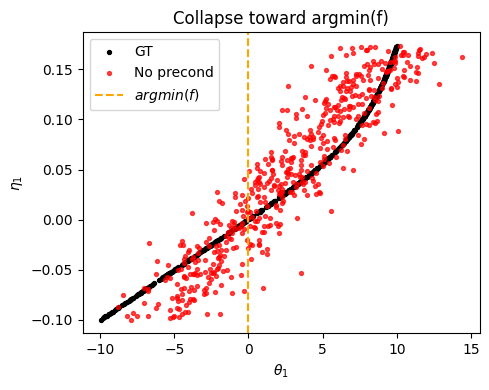

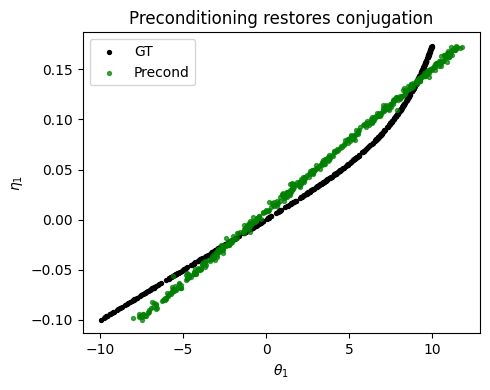

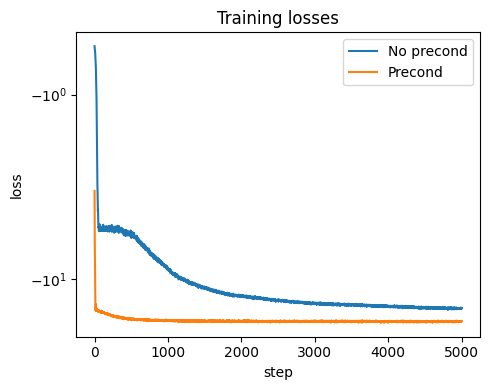

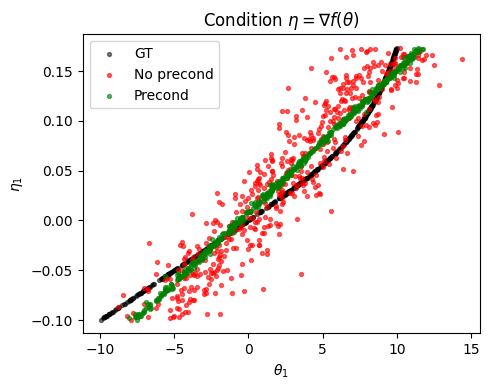

In [353]:
if __name__ == "__main__":
    #torch.manual_seed(0)
    d=128
    # Experiment 1 — baseline on a random ICNN (d=4)
    # f = experiment1_baseline(d=d)

    # # Safety check : plot f along θ₁
    # theta_line = torch.zeros(200, d, device=device)
    # theta_line[:, 0] = torch.linspace(-5, 5, 200, device=device)
    # with torch.no_grad():
    #     f_values = f(theta_line).squeeze().cpu()
    # plt.figure(figsize=(6,4))
    # plt.plot(theta_line[:, 0].cpu(), f_values)
    # plt.xlabel(r"$\theta_1$")
    # plt.ylabel(r"$f(\theta)$")
    # plt.title(r"Safety check: slice of $f$ along $\theta_1$")
    # plt.grid(True)
    # plt.show()

    # Experiment 2 — Hessian preconditioning on the same f
    # experiment2_preconditioning(f=f, d=d)

    # Experiment 3 — benchmark on 5 explicit convex functions (d=2)
    # experiment3_multifunctions(d=16)

    # Experiment 4 — matrix vs naive loss timing
    #experiment4_matrix_timing()

    # Experiment 5 - scale imbalance
    experiment5_scale_imbalance(
      d=64,
      scale=0.01
    )